# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Enter The Frontier!

And now - we put Frontier Models to the test.

### 2 important points:

It's important to appreciate that we aren't Training the frontier models. We're only providing them with the Test dataset to see how they perform. They don't gain the benefit of the 400,000 training examples that we provided to the Traditional ML models.

HAVING SAID THAT...

It's entirely possible that in their monstrously large training data, they've already been exposed to all the products in the training AND the test set. So there could be test "contamination" here which gives them an unfair advantage. We should keep that in mind.

In [8]:
# imports

import os
import re
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
from items import Item
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [9]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from testing import Tester

In [10]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [11]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [12]:
openai = OpenAI()
claude = Anthropic()

gemini_via_openai_client = OpenAI(
    api_key=os.environ['GOOGLE_API_KEY'], 
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

In [13]:
%matplotlib inline

In [14]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

# Before we look at the Frontier. The Human model

There is one more model we could consider, human prediction.

Human: average price error=126$ hits 32%

Word2Vec + RandomForest: average price error=97$ hits 34%

In [8]:
# Create the test set to a CSV

import csv
with open('human_input.csv', 'w', encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    for t in test[:250]:
        writer.writerow([t.test_prompt(), 0])

In [9]:
# Read it back in

human_predictions = []
with open('human_output.csv', 'r', encoding="utf-8") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        human_predictions.append(float(row[1]))

In [14]:
test.index(test[5])

5

In [15]:
def human_pricer(item):
    idx = test.index(item)
    return human_predictions[idx]

1: Guess: $120.00 Truth: $374.41 Error: $254.41 SLE: 1.28 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $80.00 Truth: $225.11 Error: $145.11 SLE: 1.05 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $35.00 Truth: $61.68 Error: $26.68 SLE: 0.31 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $350.00 Truth: $599.99 Error: $249.99 SLE: 0.29 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $75.00 Truth: $16.99 Error: $58.01 SLE: 2.08 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $12.00 Truth: $31.99 Error: $19.99 SLE: 0.87 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $115.00 Truth: $101.79 Error: $13.21 SLE: 0.01 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $100.00 Truth: $289.00 Error: $189.00 SLE: 1.11 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $300.00 Truth: $635.86 Error: $335.86 SLE: 0.56 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $80.00 Truth: $65.99 Error: $14.01 SLE: 0.0

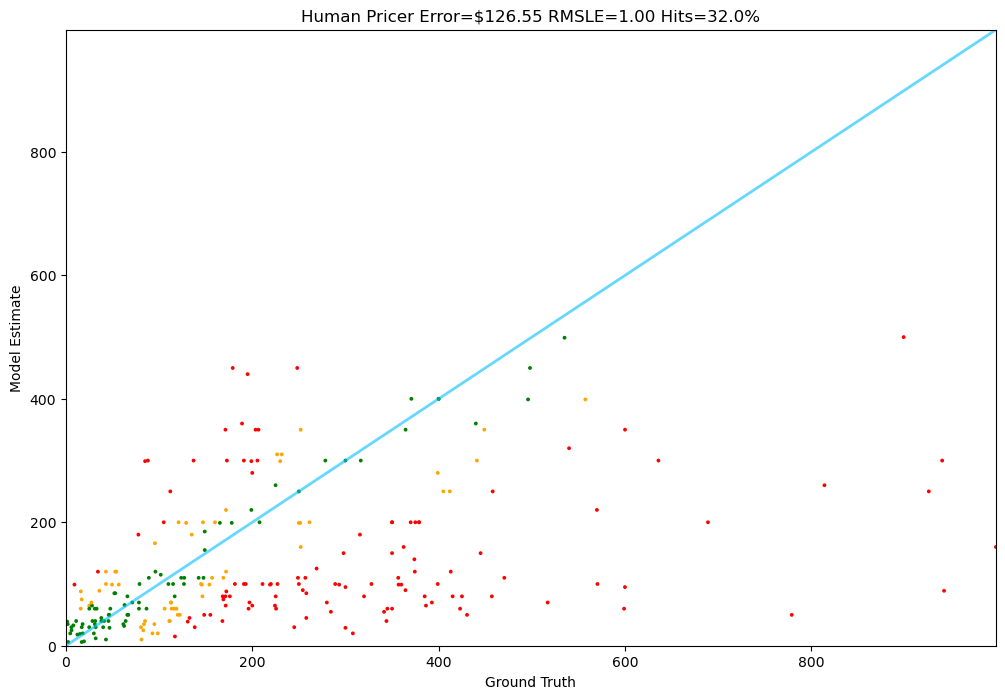

In [16]:
Tester.test(human_pricer, test)

# First, the humble but mighty GPT-4o-mini

It's called mini, but it packs a punch.

GPT-4o-mini: average price error=81$ hits 50%

Word2Vec + RandomForest: average price error=97$ hits 34%

Human: average price error=126$ hits 32%

In [15]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own open source models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        # this is to make it even more obvious to the model that we want the price. but not necesary
        {"role": "assistant", "content": "Price is $"} 
    ]

In [16]:
test[20].test_prompt()

'How much does this cost to the nearest dollar?\n\nROKINON 85mm F1.4 Auto Focus Full Frame Weather Sealed High Speed Telephoto Lens for Nikon F Mount\nDslr camera lens For Nikon F Mount full-frame & APS-C DSLR cameras Aperture range f/1.4 to f/16 Ultra multi-coated Optics; weather-sealed Takes front filter size of 77mm Constructed of 9 elements in 7 groups Dimensions 2.9 x 3.2 x 3.2 inches, Weight 1.06 pounds, model number Rank SLR Camera Lenses 1944, Available April 18, 2019, Manufacturer Rokinon, Country of Origin Korea, Republic of, Brand Rokinon, Focal Length Description 85mm, Lens Type Telephoto\n\nPrice is $'

In [17]:
# Try this out
messages_for(test[20])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nROKINON 85mm F1.4 Auto Focus Full Frame Weather Sealed High Speed Telephoto Lens for Nikon F Mount\nDslr camera lens For Nikon F Mount full-frame & APS-C DSLR cameras Aperture range f/1.4 to f/16 Ultra multi-coated Optics; weather-sealed Takes front filter size of 77mm Constructed of 9 elements in 7 groups Dimensions 2.9 x 3.2 x 3.2 inches, Weight 1.06 pounds, model number Rank SLR Camera Lenses 1944, Available April 18, 2019, Manufacturer Rokinon, Country of Origin Korea, Republic of, Brand Rokinon, Focal Length Description 85mm, Lens Type Telephoto'},
 {'role': 'assistant', 'content': 'Price is $'}]

In [18]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [19]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [60]:
# The function for gpt-4o-mini

def gpt_4o_mini(item):
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item),
        seed=42, # reproducable output
        max_tokens=5
    )
    reply = response.choices[0].message.content
    #print(reply)
    return get_price(reply)

In [61]:
print(gpt_4o_mini(test[0]))

print(test[0].price)

$180.00
180.0
374.41


1: Guess: $180.00 Truth: $374.41 Error: $194.41 SLE: 0.53 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $75.00 Truth: $225.11 Error: $150.11 SLE: 1.19 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $45.99 Truth: $61.68 Error: $15.69 SLE: 0.08 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $399.99 Truth: $599.99 Error: $200.00 SLE: 0.16 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $29.99 Truth: $16.99 Error: $13.00 SLE: 0.30 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $15.99 Truth: $31.99 Error: $16.00 SLE: 0.44 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $49.99 Truth: $101.79 Error: $51.80 SLE: 0.49 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $239.00 Truth: $289.00 Error: $50.00 SLE: 0.04 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $499.99 Truth: $635.86 Error: $135.87 SLE: 0.06 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $47.99 Truth: $65.99 Error: $18.00 SLE: 0.10 

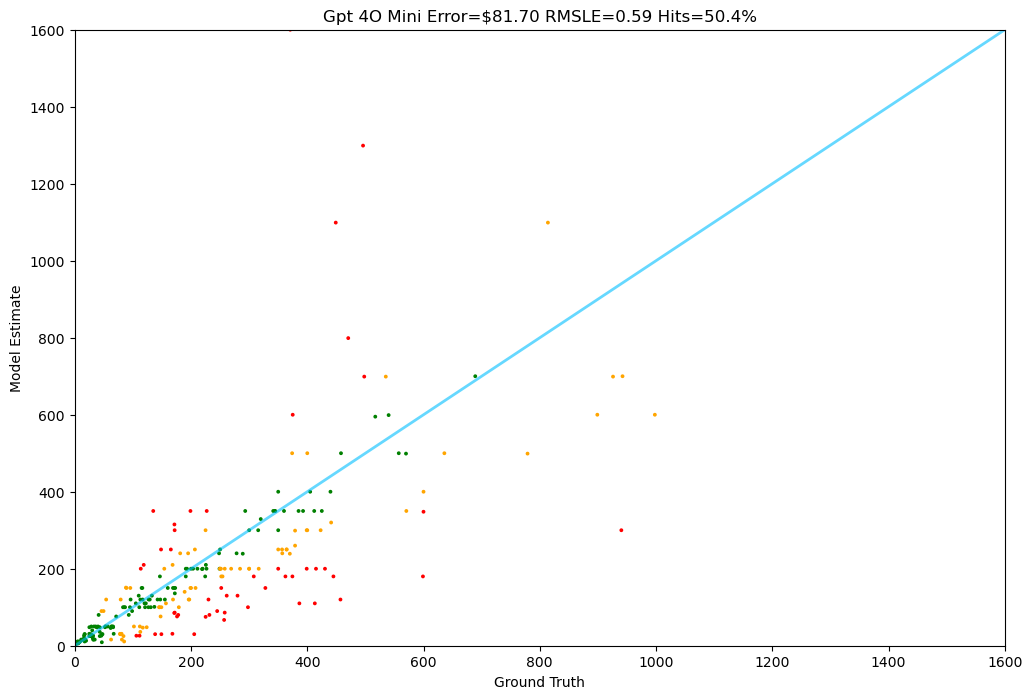

In [29]:
Tester.test(gpt_4o_mini, test)

# GPT-4o

GPT-4o: average price error=75$ hits 57%

GPT-4o-mini: average price error=81$ hits 50%

Word2Vec + RandomForest: average price error=97$ hits 34%

Human: average price error=126$ hits 32%

In [65]:
def gpt_4o_frontier(item):
    response = openai.chat.completions.create(
        model="gpt-4o-2024-08-06", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

1: Guess: $280.00 Truth: $374.41 Error: $94.41 SLE: 0.08 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $75.00 Truth: $225.11 Error: $150.11 SLE: 1.19 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $30.00 Truth: $61.68 Error: $31.68 SLE: 0.50 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $429.99 Truth: $599.99 Error: $170.00 SLE: 0.11 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $23.47 Truth: $16.99 Error: $6.48 SLE: 0.09 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $15.00 Truth: $31.99 Error: $16.99 SLE: 0.52 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $110.00 Truth: $101.79 Error: $8.21 SLE: 0.01 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $399.00 Truth: $289.00 Error: $110.00 SLE: 0.10 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $500.00 Truth: $635.86 Error: $135.86 SLE: 0.06 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $47.99 Truth: $65.99 Error: $18.00 SLE: 0.10 I

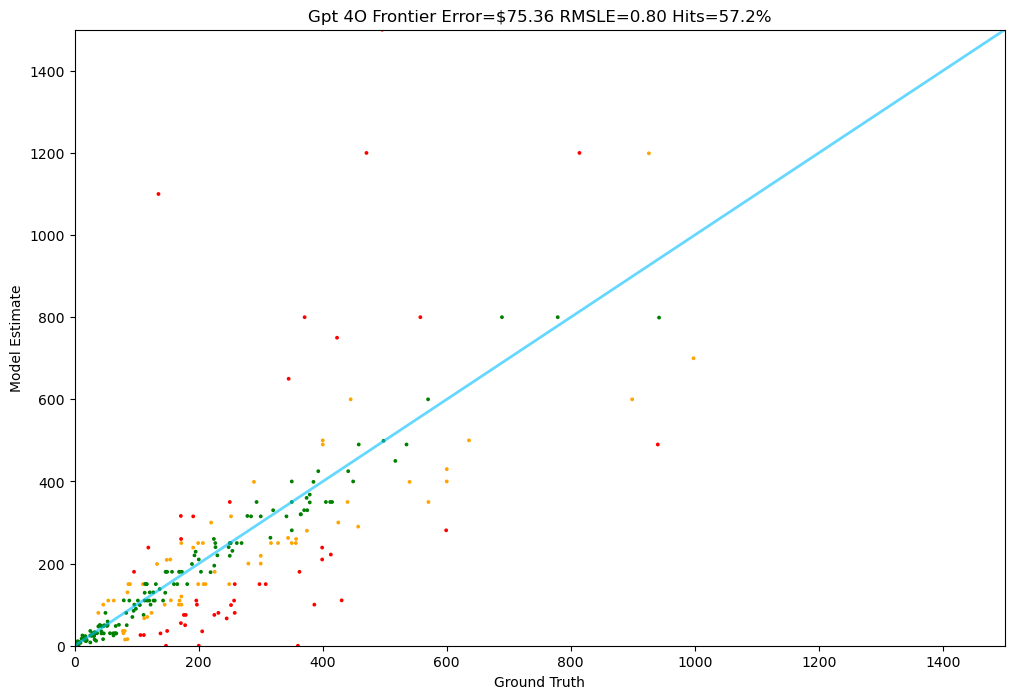

In [66]:
# The function for gpt-4o - the August model
# Note that it cost me about 1-2 cents to run this (pricing may vary by region)
# You can skip this and look at my results instead

Tester.test(gpt_4o_frontier, test)

# Claude

In [ ]:
def claude_3_point_5_sonnet(item):
    messages = messages_for(item)
    system_message = messages[0]['content']
    messages = messages[1:]
    response = claude.messages.create(
        model="claude-3-5-sonnet-20240620",
        max_tokens=5,
        system=system_message,
        messages=messages
    )
    reply = response.content[0].text
    return get_price(reply)

In [ ]:
# The function for Claude 3.5 Sonnet
# It also cost me about 1-2 cents to run this (pricing may vary by region)
# You can skip this and look at my results instead

Tester.test(claude_3_point_5_sonnet, test)

# Gemini

In [27]:
import time
def gemini_frontier(item):
    response = gemini_via_openai_client.chat.completions.create(
        model='gemini-2.0-flash-exp', #'gemini-1.5-pro'   'gemini-2.0-flash-exp'
        messages=messages_for(item),
        max_tokens=5
    )
    reply = response.choices[0].message.content
    
    # Adding a delay to avoid hitting the API rate limit and getting a "ResourceExhausted: 429" error. ONLY for geminiflash
    time.sleep(5)
    return get_price(reply)

In [28]:
print(gemini_frontier(test[0]))

print(test[0].price)

382.9
374.41


In [29]:
# I don't have a  paying account to run 250 request in less that an hour.
Tester.test(gemini_frontier, test)

1: Guess: $373.20 Truth: $374.41 Error: $1.21 SLE: 0.00 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $100.00 Truth: $225.11 Error: $125.11 SLE: 0.65 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $60.00 Truth: $61.68 Error: $1.68 SLE: 0.00 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $320.00 Truth: $599.99 Error: $279.99 SLE: 0.39 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $12.99 Truth: $16.99 Error: $4.00 SLE: 0.06 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $10.00 Truth: $31.99 Error: $21.99 SLE: 1.21 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $69.99 Truth: $101.79 Error: $31.80 SLE: 0.14 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $329.00 Truth: $289.00 Error: $40.00 SLE: 0.02 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $400.00 Truth: $635.86 Error: $235.86 SLE: 0.21 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $59.99 Truth: $65.99 Error: $6.00 SLE: 0.01 Item

RateLimitError: Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.0-flash-exp', 'location': 'global'}, 'quotaValue': '10'}]}, {'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.RetryInfo', 'retryDelay': '34s'}]}}]